In [26]:
import pandas as pd
import os

sub_entries = {}
dupe_sub_entries = {}

In [27]:
YEAR = 2025

LOG_DIR = "logs"
# os.listdir(LOG_DIR)

PAST_LOGS = [
    os.path.join(LOG_DIR, "added_to_db", "2019-8_original"),
    os.path.join(LOG_DIR, "added_to_db", "2021-10_refresh"),
    os.path.join(LOG_DIR, "added_to_db", "2021-12_all"),
    os.path.join(LOG_DIR, "added_to_db", "2021-11_new"),    
    os.path.join(LOG_DIR, "added_to_db", "2022_year"),
    os.path.join(LOG_DIR, "added_to_db", "2023_year"),
    os.path.join(LOG_DIR, "added_to_db", "2024_year"),
]

# TODO move NEW (from last year) to above PAST (and move folder into added_to_db)
NEW_LOGS = [
    os.path.join(LOG_DIR, "2025_new"), 
    os.path.join(LOG_DIR, "2025_year"),    
]

print("YEAR:", YEAR)
print("PAST_LOGS:", PAST_LOGS)
print("NEW_LOGS:", NEW_LOGS)

YEAR: 2025
PAST_LOGS: ['logs\\added_to_db\\2019-8_original', 'logs\\added_to_db\\2021-10_refresh', 'logs\\added_to_db\\2021-12_all', 'logs\\added_to_db\\2021-11_new', 'logs\\added_to_db\\2022_year', 'logs\\added_to_db\\2023_year', 'logs\\added_to_db\\2024_year']
NEW_LOGS: ['logs\\2025_new', 'logs\\2025_year']


## Collect old entries already uploaded to ytmusic

In [28]:
for path in PAST_LOGS:
    for f in sorted(os.listdir(path)):
        name, ext = os.path.splitext(f)
        if ext != '.tsv': continue
        toks = name.split('_')
        if not len(toks) == 4: continue
        sub, sort, num, timestamp = toks
        sub = sub.lower()
        if sub not in sub_entries:
            sub_entries[sub] = {}
            dupe_sub_entries[sub] = {}
        df = pd.read_csv(os.path.join(path, f), sep='\t', index_col=0)
        
        added = 0
        for i, row in df.iterrows():
            k = row.title
            if k not in sub_entries[sub]:
                sub_entries[sub][k] = row
                added+= 1
            else: # duplicate
                if k in dupe_sub_entries[sub]:
                    dupe_sub_entries[sub][k] += 1
                else: 
                    dupe_sub_entries[sub][k] = 1
        print(f'{sub}: added {added}/{len(df)} entries')

## Count results
for sub in sub_entries.keys():
    n_entries = len(sub_entries[sub])
    n_dupes = 0
    for n in dupe_sub_entries[sub].values():
        n_dupes += int(n)
    n_dupes = len(dupe_sub_entries[sub])
    print(f'{sub} has {n_entries} entries and {n_dupes} duplicate entries')

old_sub_entries = sub_entries.copy()

## Save per subreddit tsvs
old_dir = 'db\\uploaded'
for sub, entries in old_sub_entries.items():
    df = pd.DataFrame(entries).T.reset_index(drop=True)
    print(f'Saving {len(df)} old entries to {sub} tsv')
    df.to_csv(os.path.join(old_dir, f'{sub}_all.tsv'), sep='\t')


90shiphop: added 399/503 entries
blues: added 350/386 entries
chillmusic: added 580/644 entries
chillmusic: added 453/479 entries
chillwave: added 567/592 entries
chillwave: added 437/455 entries
futurebass: added 675/682 entries
futurebass: added 480/540 entries
futurebeats: added 6/6 entries
futurebeats: added 0/6 entries
futurebeats: added 18/24 entries
futurebeats: added 475/494 entries
futurebeats: added 470/486 entries
futurebeats: added 0/486 entries
futurefunkairlines: added 704/714 entries
futuregarage: added 502/513 entries
hiphop: added 483/502 entries
hiphop: added 325/609 entries
hiphopheads: added 126/126 entries
hiphopheads: added 0/126 entries
hiphopheads: added 83/126 entries
indie: added 512/533 entries
indieheads: added 101/101 entries
indierock: added 448/452 entries
jazz: added 145/152 entries
jazzyhiphop: added 589/613 entries
lofihiphop: added 206/208 entries
nudisco: added 327/332 entries
psychedelicrock: added 402/432 entries
psychedelicrock: added 210/424 entr

## Collect new entries not uploaded to ytmusic


In [29]:
new_sub_entries = {}
for path in NEW_LOGS:
    for f in sorted(os.listdir(path)):
        name, ext = os.path.splitext(f)
        if ext != '.tsv': continue
        toks = name.split('_')
        if not len(toks) == 4: continue
        sub, sort, num, timestamp = toks
        sub = sub.lower()
        if sub not in new_sub_entries:
            new_sub_entries[sub] = {}
        if sub not in sub_entries:
            sub_entries[sub] = {}
            dupe_sub_entries[sub] = {}
        df = pd.read_csv(os.path.join(path, f), sep='\t', index_col=0)
        added = 0
        for i, row in df.iterrows():
            k = row.title
            if k not in sub_entries[sub]:
                new_sub_entries[sub][k] = row
                sub_entries[sub][k] = row
                added+= 1
            else: # duplicate
                if k in dupe_sub_entries[sub]:
                    dupe_sub_entries[sub][k] += 1
                else: 
                    dupe_sub_entries[sub][k] = 1
        print(f'{sub}: added {added}/{len(df)} entries')

## Count new results
for sub in new_sub_entries.keys():
    n_entries = len(new_sub_entries[sub])
    n_dupes = 0
    for n in dupe_sub_entries[sub].values():
        n_dupes += int(n)
    n_dupes = len(dupe_sub_entries[sub])
    print(f'{sub} has new {n_entries} entries and {n_dupes} duplicate entries')

## Save per subreddit tsvs
new_dir = f'db\\new_{YEAR}'
os.makedirs(new_dir, exist_ok=True) 
for sub, entries in new_sub_entries.items():
    df = pd.DataFrame(entries).T.reset_index(drop=True)
    print(f'Saving {len(df)} new entries to {sub} tsv')
    df.to_csv(os.path.join(new_dir, f'{sub}_all.tsv'), sep='\t')


2020smusic: added 41/41 entries
afrobeat: added 90/102 entries
afropop: added 104/104 entries
artpop: added 15/15 entries
bedroompop: added 21/21 entries
blackmetal: added 14/15 entries
britpop: added 12/13 entries
choralmusic: added 60/61 entries
complextro: added 141/145 entries
cyberpunk-music: added 71/77 entries
darkjazz: added 89/91 entries
deathmetal: added 86/91 entries
desertblues: added 54/54 entries
earlymusic: added 100/101 entries
electroswing: added 66/69 entries
elitistclassical: added 128/131 entries
freejazz: added 54/55 entries
frenchrap: added 20/20 entries
bigband: added 87/89 entries
boybands: added 29/29 entries
brazilianmusic: added 73/75 entries
brostep: added 171/171 entries
celticpunk: added 92/92 entries
codingmusic: added 27/27 entries
contemporary: added 91/92 entries
dancehall: added 22/23 entries
deathcore: added 7/8 entries
djent: added 7/7 entries
dubstep: added 41/41 entries
folkmetal: added 47/49 entries
gamemusic: added 38/38 entries
garagepunk: adde

### DB Analysis (optional)

--- Starting Database Validation in 'db' ---
--- Data Collection Complete. Generating Analysis. ---

           DATABASE HEALTH REPORT

[A] Overall Summary:
  - Total Entries across all files: 194,529
  - Total Unique Subreddits found: 264
  - Years/Sources processed: ['uploaded', '2021', '2022', '2023', '2024', '2025']

[B] Top 5 Power Subreddits (by total entries):
  - deephouse                 :   4,798 entries
  - 2000smusic                :   4,373 entries
  - 2010smusic                :   4,105 entries
  - treemusic                 :   3,645 entries
  - house                     :   3,574 entries

[C] Dataset Growth (Active Subreddits per Year):
  - Year 2021       : 91 active subreddits
  - Year 2022       : 81 active subreddits
  - Year 2023       : 86 active subreddits
  - Year 2024       : 93 active subreddits
  - Year 2025       : 187 active subreddits
  - Year uploaded   : 105 active subreddits

[D] Link Source Distribution:
  - youtube.com          : 176,907 entries
  - so

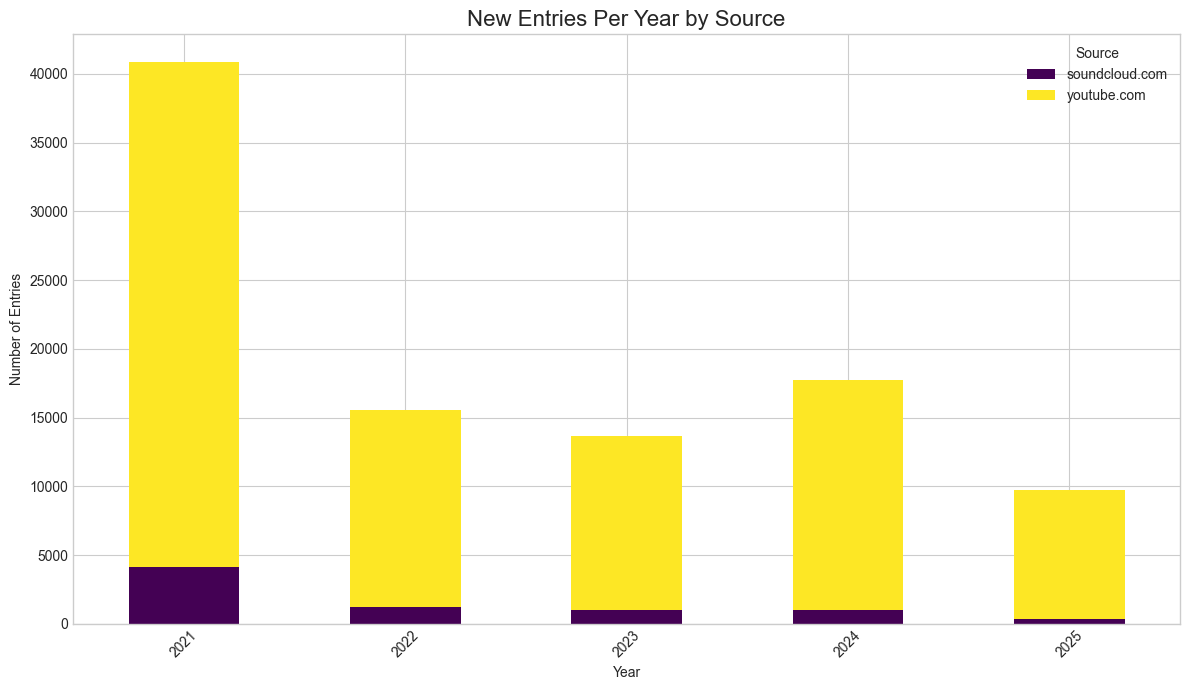


Generating visualization 3: Active Subreddits Over Time...


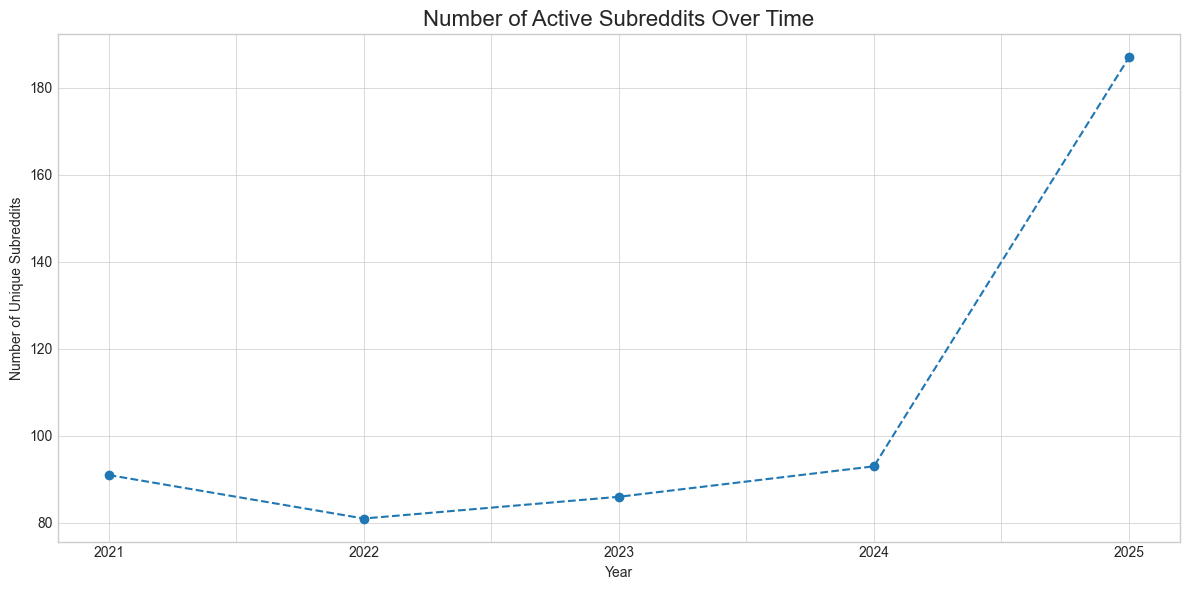

In [30]:
import pandas as pd
import os
import re
import ast # For safely parsing string representations of dictionaries
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
DB_DIR = 'db'
LOW_ENTRY_THRESHOLD = 3

# Helper function to safely parse the 'reddit' column string
def get_source_from_reddit_str(reddit_str):
    """Safely extracts the 'source' value from a stringified dictionary."""
    try:
        reddit_dict = ast.literal_eval(str(reddit_str))
        return reddit_dict.get('source', 'unknown')
    except (ValueError, SyntaxError):
        return 'unparseable'

# --- 1. Data Traversal and Collection ---
print(f"--- Starting Database Validation in '{DB_DIR}' ---")

stats = defaultdict(lambda: defaultdict(dict))
parsing_errors = defaultdict(list)
source_counts = defaultdict(int)

# Get a sorted list of directories to process: 'uploaded' first, then years chronologically.
source_dirs = sorted([d for d in os.listdir(DB_DIR) if os.path.isdir(os.path.join(DB_DIR, d))])
source_dirs.sort(key=lambda x: '0' if x == 'uploaded' else x)

for dir_name in source_dirs:
    year_label = 'uploaded'
    if 'new_' in dir_name:
        match = re.search(r'\d{4}', dir_name)
        if match:
            year_label = match.group(0)
    
    path = os.path.join(DB_DIR, dir_name)
    # The repetitive "Processing directory" print statement has been removed for cleaner output.

    for f in sorted(os.listdir(path)):
        if not f.endswith('.tsv'):
            continue
        subreddit = f.replace('_all.tsv', '')
        file_path = os.path.join(path, f)

        try:
            df = pd.read_csv(file_path, sep='\t', index_col=0)
            num_entries = len(df)
            
            source_breakdown = {}
            if num_entries > 0:
                df['source'] = df['reddit'].apply(get_source_from_reddit_str)
                source_breakdown = df['source'].value_counts().to_dict()
                for source, count in source_breakdown.items():
                    source_counts[source] += count
            
            stats[year_label][subreddit] = {
                'entries': num_entries,
                'source_counts': source_breakdown
            }
        except Exception as e:
            parsing_errors[year_label].append({'subreddit': subreddit, 'file': file_path, 'error': str(e)})
            print(f"  ERROR parsing {file_path}: {e}")

print("--- Data Collection Complete. Generating Analysis. ---")


# --- 2. Data Analysis and Reporting ---

# Main analysis DataFrame for entries per sub per year
records = [
    {'year': year, 'subreddit': sub, 'entries': data['entries']}
    for year, sub_data in stats.items()
    for sub, data in sub_data.items()
]
analysis_df = pd.DataFrame(records)
pivot_df = analysis_df.pivot_table(index='subreddit', columns='year', values='entries', fill_value=0)

# DataFrame for source breakdown per year
source_records = [
    {'year': year, 'source': source, 'count': count}
    for year, sub_data in stats.items()
    for sub, data in sub_data.items()
    for source, count in data.get('source_counts', {}).items()
]
source_by_year_df = pd.DataFrame(source_records)
yearly_source_summary = source_by_year_df.groupby(['year', 'source'])['count'].sum().unstack(fill_value=0)

# --- Report Section ---
print("\n" + "="*50)
print("           DATABASE HEALTH REPORT")
print("="*50)

# Section A: Overall Summary
print(f"\n[A] Overall Summary:")
print(f"  - Total Entries across all files: {analysis_df['entries'].sum():,}")
print(f"  - Total Unique Subreddits found: {analysis_df['subreddit'].nunique()}")
print(f"  - Years/Sources processed: {analysis_df['year'].unique().tolist()}")

# Section B: Top 5 Power Subreddits
top_subs = analysis_df.groupby('subreddit')['entries'].sum().nlargest(5)
print("\n[B] Top 5 Power Subreddits (by total entries):")
for sub, count in top_subs.items():
    print(f"  - {sub:<25} : {count:>7,} entries")

# Section C: Dataset Growth
active_subs_per_year = analysis_df[analysis_df['entries'] > 0].groupby('year')['subreddit'].nunique()
print("\n[C] Dataset Growth (Active Subreddits per Year):")
for year, count in active_subs_per_year.items():
    print(f"  - Year {year:<10} : {count} active subreddits")
    
# Section D: Link Source Distribution
print("\n[D] Link Source Distribution:")
if source_counts:
    sorted_sources = sorted(source_counts.items(), key=lambda item: item[1], reverse=True)
    for source, count in sorted_sources:
        print(f"  - {source:<20} : {count:>7,} entries")
else:
    print("  - No link sources could be parsed.")

# Section E: Subreddits with Low Entry Counts
print(f"\n[E] Subreddits to Watch (Low Entry Count < {LOW_ENTRY_THRESHOLD}):")
new_years = [col for col in pivot_df.columns if col != 'uploaded']
if new_years:
    max_entries_per_sub = pivot_df[new_years].max(axis=1)
    low_activity_subs = max_entries_per_sub[max_entries_per_sub < LOW_ENTRY_THRESHOLD]
    if not low_activity_subs.empty:
        print(f"  - Found {len(low_activity_subs)} subreddits that consistently have fewer than {LOW_ENTRY_THRESHOLD} new entries per year.")
    else:
        print("  - No subreddits found with consistently low entry counts.")

print("\n" + "="*50)


# --- 3. Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')

# # --- Figure 1: Overall Source Distribution Pie Chart ---
# print("\nGenerating visualization 1: Overall Source Distribution...")
# plt.figure(figsize=(8, 8))
# plt.pie(
#     source_counts.values(),
#     labels=source_counts.keys(),
#     autopct='%1.1f%%',
#     startangle=140,
#     colors=sns.color_palette("viridis", len(source_counts))
# )
# plt.title('Overall Link Source Distribution', fontsize=16)
# plt.show()

# --- Figure 2: Stacked Bar Chart of New Entries Per Year by Source ---
print("\nGenerating visualization 2: New Entries Per Year by Source...")
yearly_source_summary_new = yearly_source_summary.drop('uploaded', errors='ignore')
yearly_source_summary_new.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    cmap='viridis'
)
plt.title('New Entries Per Year by Source', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.show()

# --- Figure 3: Line Chart of Active Subreddits Over Time ---
print("\nGenerating visualization 3: Active Subreddits Over Time...")
active_subs_per_year_new = active_subs_per_year.drop('uploaded', errors='ignore')
active_subs_per_year_new.plot(
    kind='line',
    marker='o',
    linestyle='--',
    figsize=(12, 6)
)
plt.title('Number of Active Subreddits Over Time', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Unique Subreddits')
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Figure 4: Stacked Horizontal Bar Chart (COMMENTED OUT) ---

# # This plot is very large and can be slow to render. Uncomment to generate it.
# print("\nGenerating visualization 4: Stacked Bar Chart per Subreddit (this may be large)...")
# pivot_df['total'] = pivot_df.sum(axis=1)
# pivot_df_sorted = pivot_df.sort_values('total', ascending=True).drop(columns=['total'])
# fig_height = max(8, len(pivot_df) * 0.3)
# pivot_df_sorted.plot(
#     kind='barh', stacked=True, figsize=(12, fig_height), width=0.8, cmap='viridis'
# )
# plt.title('Entries per Subreddit by Year', fontsize=16)
# plt.xlabel('Total Number of Entries')
# plt.ylabel('Subreddit')
# plt.legend(title='Year/Source')
# plt.tight_layout()
# plt.show()

# --- Figure 5: Full Heatmap of Entries per Subreddit per Year ---
# print("\nGenerating visualization 5: Full Heatmap...")
# num_subreddits = len(pivot_df)
# fig_height = max(10, num_subreddits * 0.4)
# plt.figure(figsize=(14, fig_height))
# sns.heatmap(
#     pivot_df, cmap='viridis', annot=True, fmt='.0f',
#     linewidths=.5, cbar_kws={'label': 'Number of Entries'}
# )
# plt.title('Heatmap of Entries per Subreddit per Year', fontsize=16)
# plt.xlabel('Year / Source')
# plt.ylabel('Subreddit')
# plt.tight_layout()
# plt.show()


In [31]:
low_activity_subs

subreddit
90spunk               0.0
classicrock           0.0
doommetal             0.0
futurefunkairlines    0.0
gfunk                 0.0
headnodders           0.0
musictosleepto        0.0
rock                  0.0
tropicalhouse         0.0
dtype: float64